# Dataset Statistics
Analyze metadata distributions for spacing and volume size, and quantify calcium voxel class imbalance.

Outputs saved:
- `docs/images/spacing_distribution.png`
- `docs/images/volume_size_distribution.png`
- `docs/images/calcium_fraction_summary.png`
- `experiments/dataset_statistics_summary.csv`

In [ ]:
from pathlib import Path
import subprocess
import sys

import nibabel as nib
import numpy as np
import pandas as pd
from pandas.errors import EmptyDataError
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

metadata_csv = ROOT / 'data' / 'metadata.csv'
ingest_script = ROOT / 'scripts' / 'run_ingest.py'
mask_dir = ROOT / 'data' / 'masks'
docs_img_dir = ROOT / 'docs' / 'images'
experiments_dir = ROOT / 'experiments'
docs_img_dir.mkdir(parents=True, exist_ok=True)
experiments_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
print(f'Using metadata file: {metadata_csv}')

Using metadata file: C:\Users\karth\PrediCT\data\metadata.csv


In [ ]:
df = pd.DataFrame()

try:
    needs_generation = (not metadata_csv.exists()) or (metadata_csv.stat().st_size == 0)
except OSError:
    needs_generation = True

if needs_generation:
    print('metadata.csv is missing or empty. Running ingestion to generate metadata...')
    if not ingest_script.exists():
        raise FileNotFoundError(f'Ingest script not found: {ingest_script}')
    subprocess.run([sys.executable, str(ingest_script)], cwd=str(ROOT), check=True)

try:
    df = pd.read_csv(metadata_csv)
except EmptyDataError:
    print('metadata.csv exists but is empty after ingestion.')
    df = pd.DataFrame()
except FileNotFoundError:
    print('metadata.csv could not be found after ingestion.')
    df = pd.DataFrame()

if df.empty:
    print('Falling back to demo-data metadata generation...')
    from predict_cac.utils.synthetic_data import generate_synthetic_demo_data
    from predict_cac.data.metadata_builder import build_metadata_csv

    generate_synthetic_demo_data(ROOT, seed=42)
    build_metadata_csv(ROOT / 'data' / 'nifti', metadata_csv)
    try:
        df = pd.read_csv(metadata_csv)
    except EmptyDataError:
        df = pd.DataFrame()

if df.empty:
    print('Rows: 0 (no scans available yet)')
else:
    print(f'Rows: {len(df)}')
    display(df.head())

Rows: 2


,patient_id,scan_id,nifti_path,slice_thickness,spacing_x,spacing_y,spacing_z,size_x,size_y,size_z
0,sample,sample_fixed,C:\Users\karth\PrediCT\data\nifti\sample_fixed...,1.0,1.0,1.0,1.0,128,128,64
1,sample,sample_moving,C:\Users\karth\PrediCT\data\nifti\sample_movin...,1.0,1.0,1.0,1.0,128,128,64


In [ ]:
numeric_cols = ['slice_thickness', 'spacing_x', 'spacing_y', 'spacing_z', 'size_x', 'size_y', 'size_z']
available_numeric_cols = [c for c in numeric_cols if c in df.columns]

if df.empty:
    print('No metadata rows available to summarize.')
    summary_df = pd.DataFrame()
elif not available_numeric_cols:
    print('No expected numeric columns found in metadata.csv.')
    summary_df = pd.DataFrame()
else:
    summary_df = df[available_numeric_cols].describe().T
    display(summary_df)

from typing import cast

mask_paths = sorted(mask_dir.glob('*.nii.gz'))
calcium_fractions = []
total_voxels = 0
total_calcium_voxels = 0

for mask_path in mask_paths:
    mask_img = cast(nib.Nifti1Image, nib.load(str(mask_path)))
    mask = np.asarray(mask_img.get_fdata()) > 0
    voxels = int(mask.size)
    calcium_voxels = int(mask.sum())
    total_voxels += voxels
    total_calcium_voxels += calcium_voxels
    calcium_fractions.append({
        'mask': mask_path.name,
        'calcium_fraction': (calcium_voxels / voxels) if voxels > 0 else 0.0,
    })

calcium_fraction_df = pd.DataFrame(calcium_fractions)
global_calcium_fraction = (total_calcium_voxels / total_voxels) if total_voxels > 0 else 0.0
print(f'Global calcium voxel fraction: {global_calcium_fraction:.6f}')

summary_payload = {
    'n_scans': int(len(df)),
    'n_masks': int(len(mask_paths)),
    'global_calcium_voxel_fraction': float(global_calcium_fraction),
}
summary_out = pd.DataFrame([summary_payload])
summary_out.to_csv(experiments_dir / 'dataset_statistics_summary.csv', index=False)
print(f"Saved summary table to: {experiments_dir / 'dataset_statistics_summary.csv'}")

,count,mean,std,min,25%,50%,75%,max
slice_thickness,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
spacing_x,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
spacing_y,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
spacing_z,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
size_x,2.0,128.0,0.0,128.0,128.0,128.0,128.0,128.0
size_y,2.0,128.0,0.0,128.0,128.0,128.0,128.0,128.0
size_z,2.0,64.0,0.0,64.0,64.0,64.0,64.0,64.0


Global calcium voxel fraction: 0.000872
Saved summary table to: C:\Users\karth\PrediCT\experiments\dataset_statistics_summary.csv


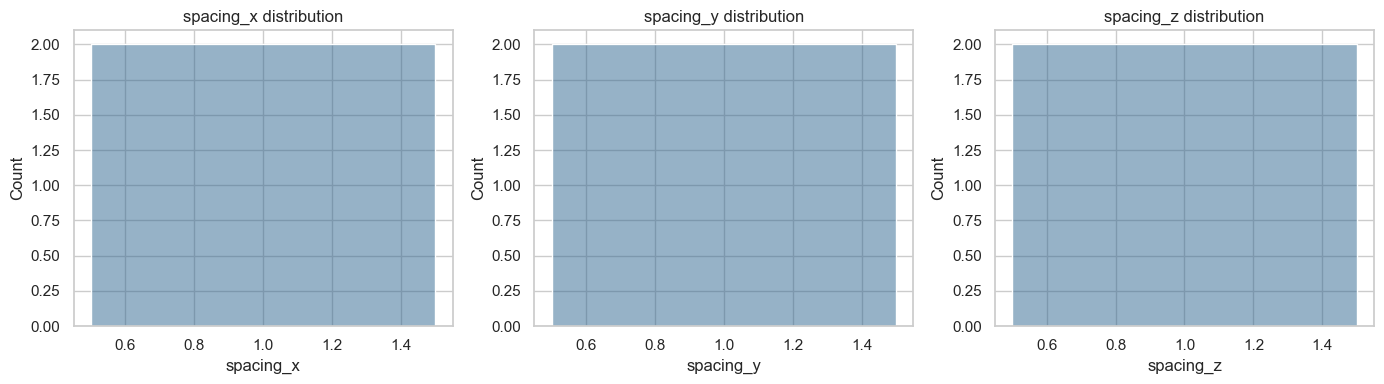

Saved: C:\Users\karth\PrediCT\docs\images\spacing_distribution.png


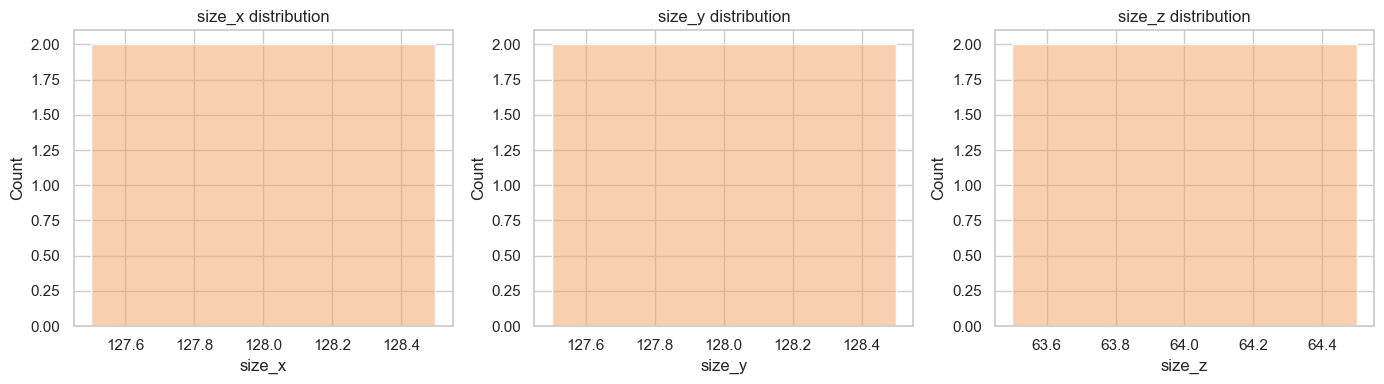

Saved: C:\Users\karth\PrediCT\docs\images\volume_size_distribution.png


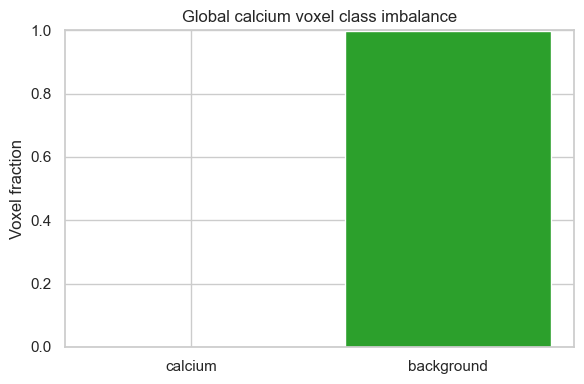

Saved: C:\Users\karth\PrediCT\docs\images\calcium_fraction_summary.png


,calcium_fraction
count,1.000000
mean,0.000872
std,NaN
min,0.000872
25%,0.000872
50%,0.000872
75%,0.000872
max,0.000872


In [ ]:
if not df.empty and {'spacing_x', 'spacing_y', 'spacing_z'}.issubset(df.columns):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for idx, col in enumerate(['spacing_x', 'spacing_y', 'spacing_z']):
        sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='#2f6690')
        axes[idx].set_title(f'{col} distribution')
    plt.tight_layout()
    spacing_out = docs_img_dir / 'spacing_distribution.png'
    fig.savefig(spacing_out, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {spacing_out}')
else:
    print('Spacing columns missing; skipping spacing plots.')

if not df.empty and {'size_x', 'size_y', 'size_z'}.issubset(df.columns):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for idx, col in enumerate(['size_x', 'size_y', 'size_z']):
        sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='#f4a261')
        axes[idx].set_title(f'{col} distribution')
    plt.tight_layout()
    size_out = docs_img_dir / 'volume_size_distribution.png'
    fig.savefig(size_out, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {size_out}')
else:
    print('Volume size columns missing; skipping size plots.')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar(['calcium', 'background'], [global_calcium_fraction, 1.0 - global_calcium_fraction], color=['#d62728', '#2ca02c'])
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('Voxel fraction')
ax.set_title('Global calcium voxel class imbalance')
plt.tight_layout()
imbalance_out = docs_img_dir / 'calcium_fraction_summary.png'
fig.savefig(imbalance_out, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {imbalance_out}')

if not calcium_fraction_df.empty:
    display(calcium_fraction_df.describe())